<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen029.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid and attractors
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
theta = np.pi / 3

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

# Two attractors separated by barrier
left = gaussian(np.pi/3, sigma, A) * np.cos(theta)
right = gaussian(5*np.pi/3, sigma, A) * np.cos(theta)
barrier = -0.05 * np.exp(-((x - np.pi)**2) / (2 * 0.1**2))  # narrow dip at center
phi = left + right + barrier
history = [phi.copy()]


In [3]:
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)

for t in range(300):
    phi = evolve(phi)
    if t % 10 == 0:
        history.append(phi.copy())


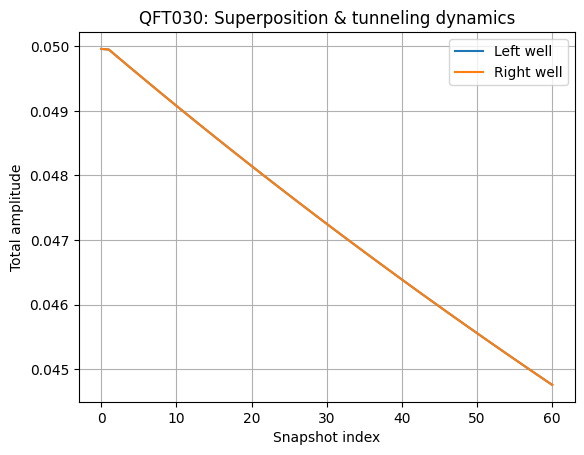

In [4]:
from scipy.signal import find_peaks

left_zone = (x < np.pi)
right_zone = (x > np.pi)

left_amplitudes = []
right_amplitudes = []

for snapshot in history:
    peaks, _ = find_peaks(snapshot, height=0.02)
    left_peaks = [p for p in peaks if left_zone[p]]
    right_peaks = [p for p in peaks if right_zone[p]]
    left_amplitudes.append(np.sum(snapshot[left_peaks]))
    right_amplitudes.append(np.sum(snapshot[right_peaks]))

plt.plot(left_amplitudes, label="Left well")
plt.plot(right_amplitudes, label="Right well")
plt.xlabel("Snapshot index")
plt.ylabel("Total amplitude")
plt.title("QFT030: Superposition & tunneling dynamics")
plt.legend()
plt.grid(True)
plt.show()
